In [1]:
import numpy as np
import pandas as pd
from kneed import KneeLocator
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

🔵 TRAIN AND TEST LASSO REGRESSION ON B2 MICROGLOBULIN

                                               Feature    Weight
0                       original_shape_MajorAxisLength  0.939938
1                    original_shape_SurfaceVolumeRatio  0.448924
2                 gradient_gldm_GrayLevelNonUniformity  0.405301
3    gradient_gldm_LargeDependenceHighGrayLevelEmph...  0.284570
4                                    original_glcm_MCC  0.248328
..                                                 ...       ...
196                      original_glszm_ZonePercentage -0.449097
197                   original_shape_Maximum3DDiameter -0.461047
198                                          n_lesions -0.478532
199                          gradient_ngtdm_Coarseness -0.562481
200                                 gradient_glcm_Imc1 -0.766993

[201 rows x 2 columns]
 Selected features: ['original_shape_MajorAxisLength', 'original_shape_SurfaceVolumeRatio', 'gradient_gldm_GrayLevelNonUniformity', 'gradient_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_

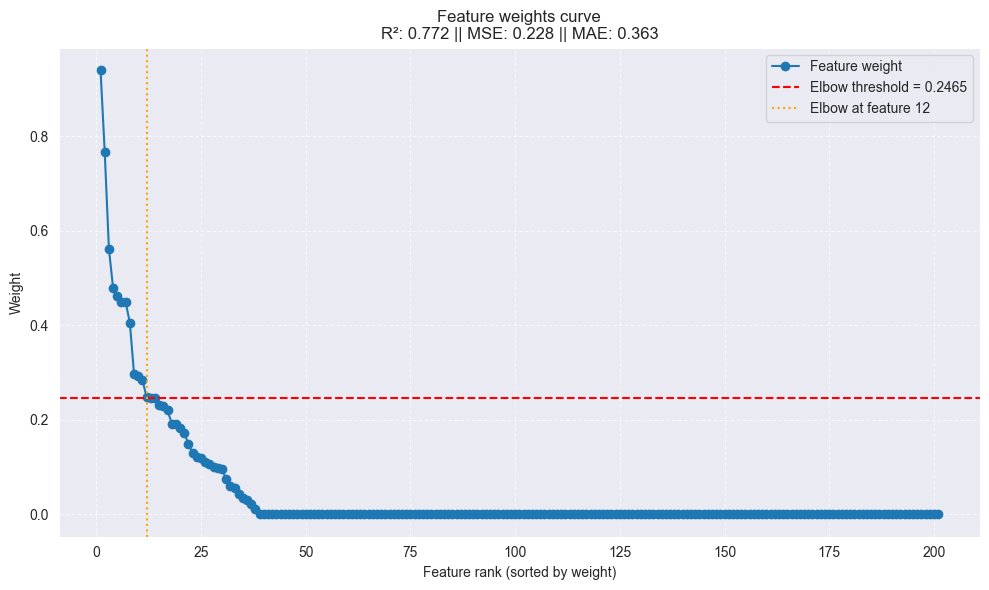

In [14]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical = clinical_df.select_dtypes(include=['number']).columns

features_df = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns

scaler = StandardScaler()
clinical_scaled = pd.DataFrame(scaler.fit_transform(clinical_df[numeric_clinical]),
                               columns=clinical_df[numeric_clinical].columns,
                               index=clinical_df[numeric_clinical].index)
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_df[numeric_features]),
                               columns=features_df[numeric_features].columns,
                               index=features_df[numeric_features].index)

valid_idx = clinical_scaled['Beta2 microglobulin (mg/l)'].notna()
lasso = Lasso(alpha=0.01, random_state=42)

X = features_scaled[numeric_features][valid_idx]
y = clinical_scaled['Beta2 microglobulin (mg/l)'][valid_idx]

lasso.fit(X, y)
y_pred = lasso.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

feature_weights_df = pd.DataFrame({'Feature': X.columns, 'Weight': lasso.coef_}).sort_values(by='Weight', ascending=False).reset_index(drop=True)
print(feature_weights_df)

imp = np.sort(np.abs(feature_weights_df['Weight'].values))[::-1]
x = np.arange(1, len(imp) + 1)

knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
threshold = imp[knee.knee] if knee.knee is not None else None
selected_features = feature_weights_df[feature_weights_df['Weight'].abs() > threshold]['Feature'].tolist()
print(f" Selected features: {selected_features}")

plt.figure(figsize=(10, 6))
plt.plot(x, imp, marker='o', label='Feature weight')
if threshold is not None:
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
    plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
plt.title(f"Feature weights curve\nR²: {r2:.3f} || MSE: {mse:.3f} || MAE: {mae:.3f}")
plt.xlabel("Feature rank (sorted by weight)")
plt.ylabel("Weight")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

🔵 LASSO FOR EVERY DATASET

CaSupp_25
                                               Feature    Weight
0                       original_shape_MajorAxisLength  0.939938
1                    original_shape_SurfaceVolumeRatio  0.448924
2                 gradient_gldm_GrayLevelNonUniformity  0.405301
3    gradient_gldm_LargeDependenceHighGrayLevelEmph...  0.284570
4                                    original_glcm_MCC  0.248328
..                                                 ...       ...
196                      original_glszm_ZonePercentage -0.449097
197                   original_shape_Maximum3DDiameter -0.461047
198                                          n_lesions -0.478532
199                          gradient_ngtdm_Coarseness -0.562481
200                                 gradient_glcm_Imc1 -0.766993

[201 rows x 2 columns]
 Selected features: ['original_shape_MajorAxisLength', 'original_shape_SurfaceVolumeRatio', 'gradient_gldm_GrayLevelNonUniformity', 'gradient_gldm_LargeDependenceHighGrayLevelEmphasis', 

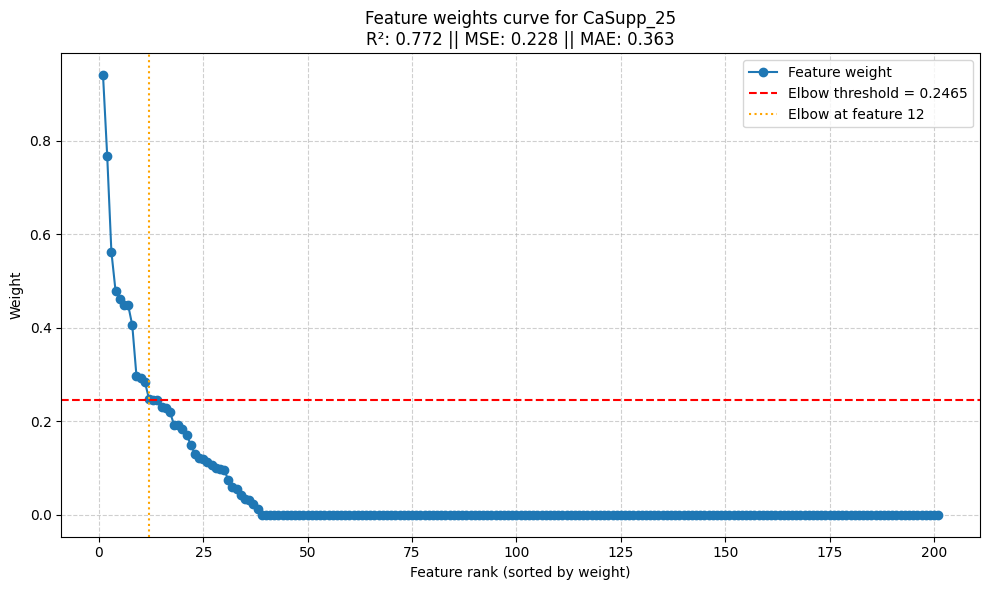

Konv
                                               Feature    Weight
0                       original_shape_MajorAxisLength  0.927288
1         gradient_glszm_SmallAreaLowGrayLevelEmphasis  0.516537
2      gradient_firstorder_RobustMeanAbsoluteDeviation  0.433293
3                           original_firstorder_Energy  0.397186
4    original_gldm_LargeDependenceLowGrayLevelEmphasis  0.366835
..                                                 ...       ...
196  gradient_gldm_SmallDependenceLowGrayLevelEmphasis -0.281071
197              original_shape_Maximum2DDiameterSlice -0.283610
198                                          n_lesions -0.308328
199                   original_shape_Maximum3DDiameter -0.384362
200                    gradient_firstorder_TotalEnergy -0.390366

[201 rows x 2 columns]
 Selected features: ['original_shape_MajorAxisLength', 'gradient_glszm_SmallAreaLowGrayLevelEmphasis', 'gradient_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_Energy', 'origin

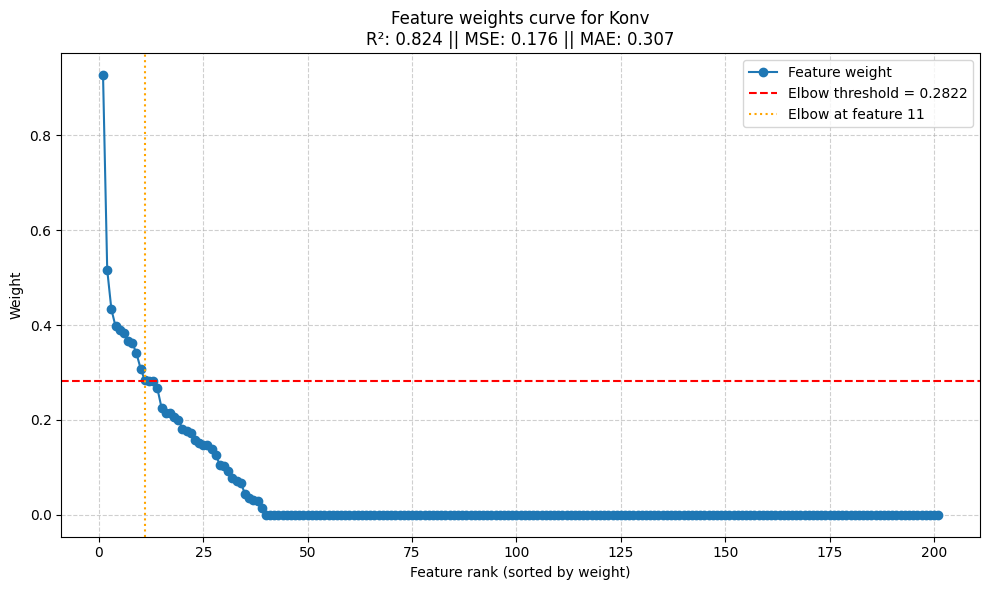

VMI_40
                                               Feature    Weight
0                       original_shape_MajorAxisLength  1.022180
1                         original_firstorder_Skewness  0.463990
2                           original_firstorder_Energy  0.417783
3              original_glszm_LowGrayLevelZoneEmphasis  0.390197
4                  original_firstorder_RootMeanSquared  0.315715
..                                                 ...       ...
196                          original_glcm_JointEnergy -0.300498
197                   original_shape_Maximum3DDiameter -0.365569
198                        original_firstorder_Minimum -0.418418
199  gradient_gldm_SmallDependenceLowGrayLevelEmphasis -0.457711
200                                          n_lesions -0.485925

[201 rows x 2 columns]
 Selected features: ['original_shape_MajorAxisLength', 'original_firstorder_Skewness', 'original_firstorder_Energy', 'original_glszm_LowGrayLevelZoneEmphasis', 'original_firstorder_RootMean

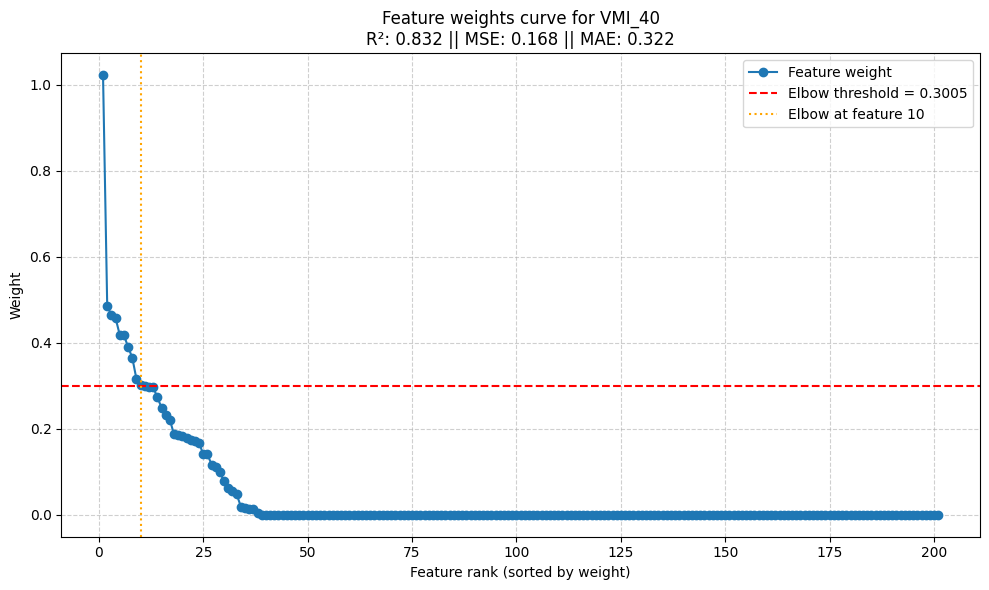

VMI_80
                              Feature    Weight
0      original_shape_MajorAxisLength  0.844429
1     original_firstorder_TotalEnergy  0.572799
2             original_ngtdm_Strength  0.425967
3          original_glcm_ClusterShade  0.399109
4              gradient_glcm_Contrast  0.342410
..                                ...       ...
196  original_shape_Maximum3DDiameter -0.287187
197           gradient_ngtdm_Strength -0.338212
198   gradient_firstorder_TotalEnergy -0.376510
199         gradient_glcm_Correlation -0.559445
200                gradient_glcm_Imc1 -0.662212

[201 rows x 2 columns]
 Selected features: ['original_shape_MajorAxisLength', 'original_firstorder_TotalEnergy', 'original_ngtdm_Strength', 'original_glcm_ClusterShade', 'gradient_glcm_Contrast', 'gradient_glszm_SmallAreaLowGrayLevelEmphasis', 'original_shape_LeastAxisLength', 'original_glszm_SizeZoneNonUniformityNormalized', 'original_glcm_MCC', 'original_ngtdm_Busyness', 'original_ngtdm_Contrast', 'original_glr

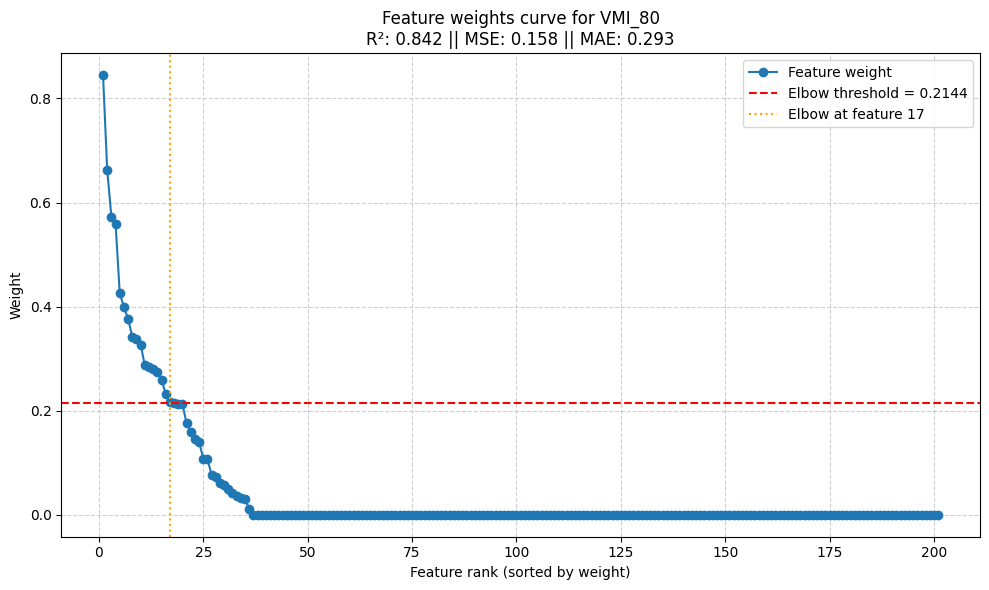

VMI_120
                                               Feature    Weight
0                       original_shape_MajorAxisLength  0.842203
1                            original_ngtdm_Complexity  0.545350
2                              original_ngtdm_Busyness  0.500664
3    original_gldm_LargeDependenceLowGrayLevelEmphasis  0.490108
4       original_glszm_SizeZoneNonUniformityNormalized  0.479168
..                                                 ...       ...
196                                          n_lesions -0.229496
197              original_shape_Maximum2DDiameterSlice -0.241993
198                                 gradient_glcm_Idmn -0.255878
199                    gradient_firstorder_TotalEnergy -0.443239
200                            original_ngtdm_Contrast -0.448873

[201 rows x 2 columns]
 Selected features: ['original_shape_MajorAxisLength', 'original_ngtdm_Complexity', 'original_ngtdm_Busyness', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glszm_SizeZone

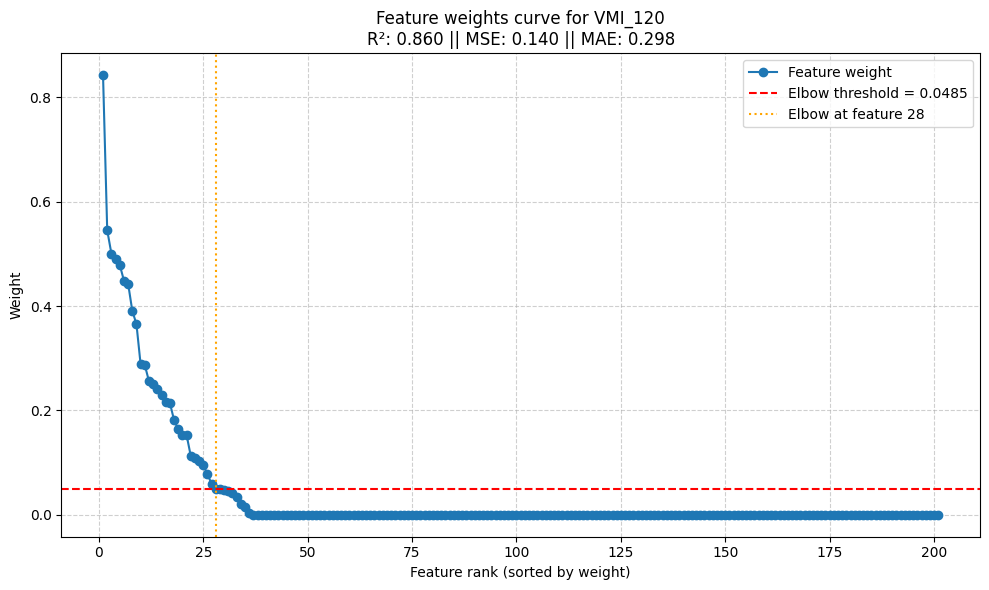

In [6]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical = clinical_df.select_dtypes(include=['number']).columns

scaler = StandardScaler()
clinical_scaled = pd.DataFrame(scaler.fit_transform(clinical_df[numeric_clinical]),
                               columns=clinical_df[numeric_clinical].columns,
                               index=clinical_df[numeric_clinical].index)

df_c25 = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged\merged_konv_radiomics_spine_lesions_features.csv")

dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

for df, name in zip(dfs, dataset_names):
    numeric_features = df.select_dtypes(include=['number']).columns

    scaler = StandardScaler()
    features_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_features]),
                                   columns=df[numeric_features].columns,
                                   index=df[numeric_features].index)

    valid_idx = clinical_scaled['Beta2 microglobulin (mg/l)'].notna()
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=5000)

    X = features_scaled[numeric_features][valid_idx]
    y = clinical_scaled['Beta2 microglobulin (mg/l)'][valid_idx]

    lasso.fit(X, y)
    y_pred = lasso.predict(X)

    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    feature_weights_df = pd.DataFrame({'Feature': X.columns, 'Weight': lasso.coef_}).sort_values(by='Weight', ascending=False).reset_index(drop=True)
    print(name)
    print(feature_weights_df)

    imp = np.sort(np.abs(feature_weights_df['Weight'].values))[::-1]
    x = np.arange(1, len(imp) + 1)

    knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
    threshold = imp[knee.knee] if knee.knee is not None else None
    selected_features = feature_weights_df[feature_weights_df['Weight'].abs() > threshold]['Feature'].tolist()
    print(f" Selected features: {selected_features}")

    plt.figure(figsize=(10, 6))
    plt.plot(x, imp, marker='o', label='Feature weight')
    if threshold is not None:
        plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
        plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
    plt.title(f"Feature weights curve for {name}\nR²: {r2:.3f} || MSE: {mse:.3f} || MAE: {mae:.3f}")
    plt.xlabel("Feature rank (sorted by weight)")
    plt.ylabel("Weight")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

🔵 LASSO FOR EVERY DATASET AND JUST SIGNIFICANT FEATURES

CaSupp_25
                                            Feature    Weight
0                  gradient_firstorder_90Percentile  0.361174
1                  gradient_gldm_DependenceVariance  0.321074
2         original_firstorder_MeanAbsoluteDeviation  0.247478
3   original_glszm_GrayLevelNonUniformityNormalized  0.214876
4                      original_firstorder_Kurtosis  0.179818
..                                              ...       ...
95           gradient_glrlm_LowGrayLevelRunEmphasis -0.276104
96                       original_firstorder_Median -0.312193
97                       original_glszm_ZoneEntropy -0.339129
98                               gradient_glcm_Imc1 -0.346759
99           gradient_firstorder_InterquartileRange -0.565485

[100 rows x 2 columns]
 Selected features: ['gradient_firstorder_90Percentile', 'gradient_gldm_DependenceVariance', 'original_firstorder_MeanAbsoluteDeviation', 'original_glszm_GrayLevelNonUniformityNormalized', 'original_firstorder_Kurtosis', '

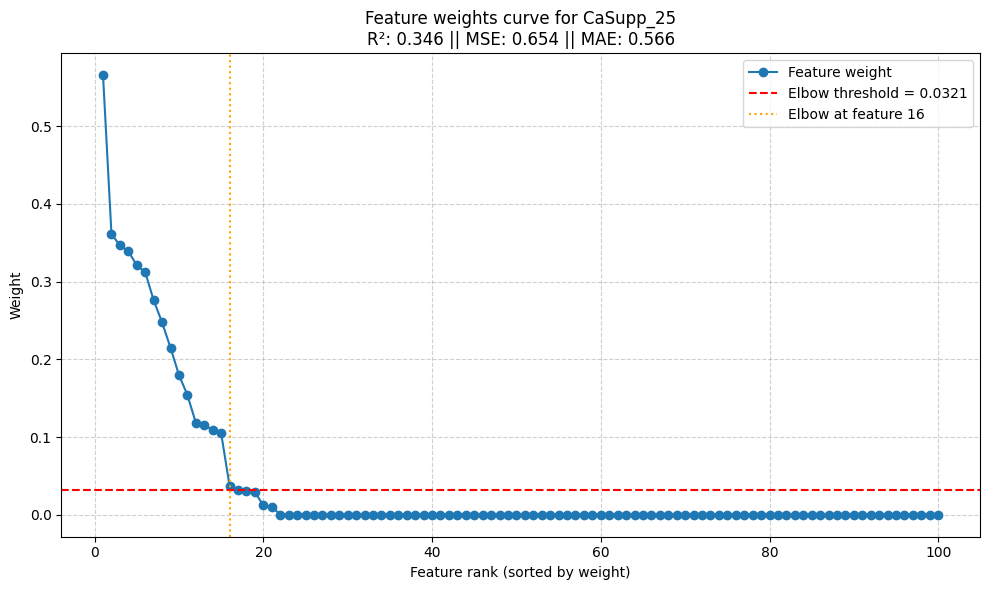

Konv
                                               Feature    Weight
0               original_firstorder_InterquartileRange  0.706189
1                               original_glcm_Contrast  0.457280
2                     original_firstorder_10Percentile  0.379476
3    original_gldm_LargeDependenceLowGrayLevelEmphasis  0.370725
4                                    gradient_glcm_MCC  0.271323
..                                                 ...       ...
102    gradient_glrlm_GrayLevelNonUniformityNormalized -0.280859
103                         gradient_glszm_ZoneEntropy -0.394208
104    gradient_glszm_GrayLevelNonUniformityNormalized -0.417080
105                   gradient_glszm_GrayLevelVariance -0.466613
106                            original_ngtdm_Contrast -0.599892

[107 rows x 2 columns]
 Selected features: ['original_firstorder_InterquartileRange', 'original_glcm_Contrast', 'original_firstorder_10Percentile', 'original_gldm_LargeDependenceLowGrayLevelEmphasis', 'gradient_glc

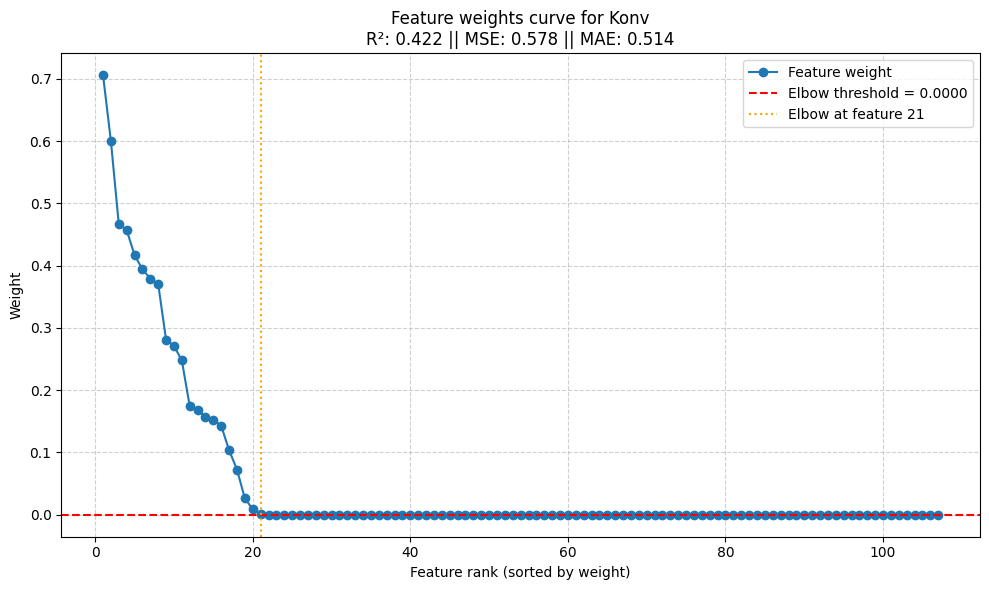

VMI_40
                                               Feature    Weight
0    gradient_gldm_LargeDependenceLowGrayLevelEmphasis  0.395337
1           original_glrlm_LongRunLowGrayLevelEmphasis  0.267351
2                                   original_glcm_Idmn  0.236307
3                         original_firstorder_Kurtosis  0.226730
4               gradient_firstorder_InterquartileRange  0.052020
..                                                 ...       ...
104                   gradient_gldm_DependenceVariance -0.351218
105    original_glszm_GrayLevelNonUniformityNormalized -0.447010
106                   original_glcm_MaximumProbability -0.455056
107                   original_glcm_DifferenceVariance -0.465459
108                         original_glszm_ZoneEntropy -0.644782

[109 rows x 2 columns]
 Selected features: ['gradient_gldm_LargeDependenceLowGrayLevelEmphasis', 'original_glrlm_LongRunLowGrayLevelEmphasis', 'original_glcm_Idmn', 'original_firstorder_Kurtosis', 'gradient_first

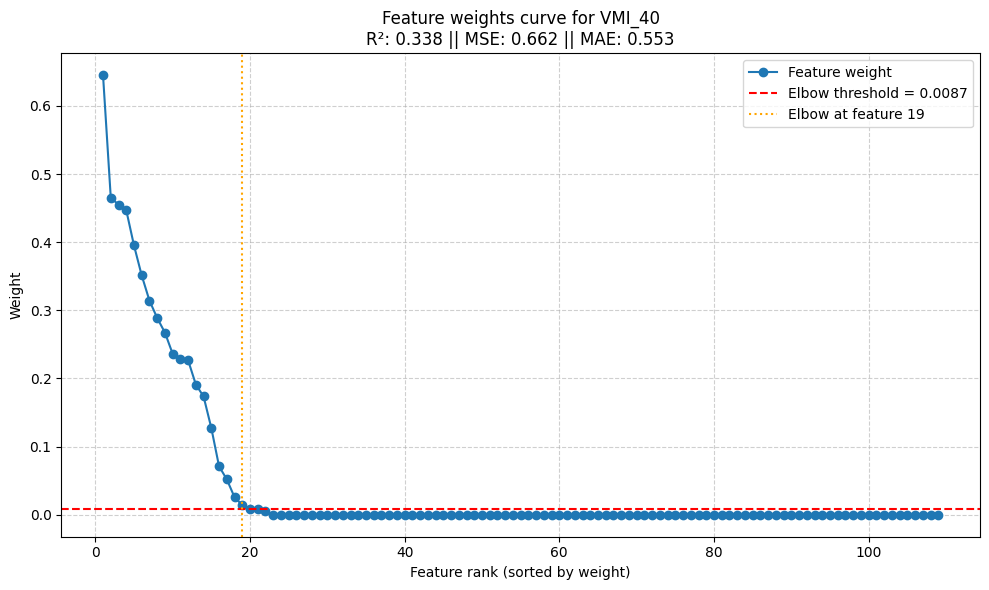

VMI_80
                                               Feature    Weight
0               original_firstorder_InterquartileRange  0.899421
1    gradient_gldm_SmallDependenceLowGrayLevelEmphasis  0.426912
2                     gradient_firstorder_90Percentile  0.369716
3                     original_firstorder_10Percentile  0.334238
4      gradient_firstorder_RobustMeanAbsoluteDeviation  0.205529
..                                                 ...       ...
103                      gradient_glszm_ZonePercentage -0.223733
104                                 gradient_glcm_Imc1 -0.493867
105                         gradient_glszm_ZoneEntropy -0.502739
106                            original_ngtdm_Contrast -0.600494
107                        original_firstorder_Entropy -0.667501

[108 rows x 2 columns]
 Selected features: ['original_firstorder_InterquartileRange', 'gradient_gldm_SmallDependenceLowGrayLevelEmphasis', 'gradient_firstorder_90Percentile', 'original_firstorder_10Percentile', '

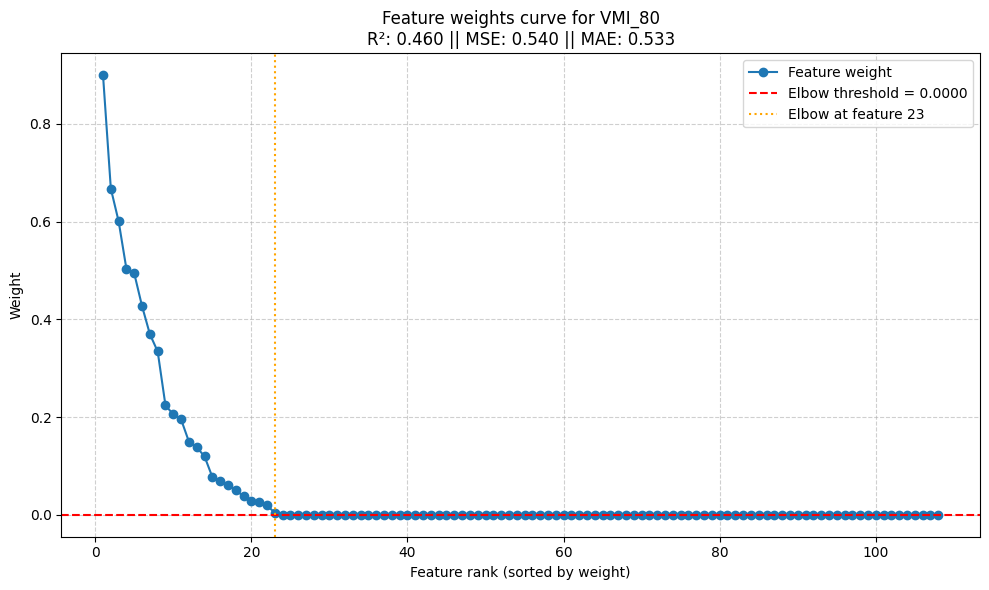

VMI_120
                                             Feature    Weight
0       original_glszm_LargeAreaLowGrayLevelEmphasis  0.781939
1             original_firstorder_InterquartileRange  0.702544
2                   original_firstorder_10Percentile  0.516592
3                   gradient_glcm_DifferenceVariance  0.288087
4             gradient_firstorder_InterquartileRange  0.275020
..                                               ...       ...
101    original_glszm_LargeAreaHighGrayLevelEmphasis -0.623186
102    gradient_glszm_SmallAreaHighGrayLevelEmphasis -0.664680
103                          original_ngtdm_Contrast -0.672169
104  original_glszm_GrayLevelNonUniformityNormalized -0.745740
105                       original_glszm_ZoneEntropy -0.879867

[106 rows x 2 columns]
 Selected features: ['original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_firstorder_InterquartileRange', 'original_firstorder_10Percentile', 'gradient_glcm_DifferenceVariance', 'gradient_firstorder_Interqua

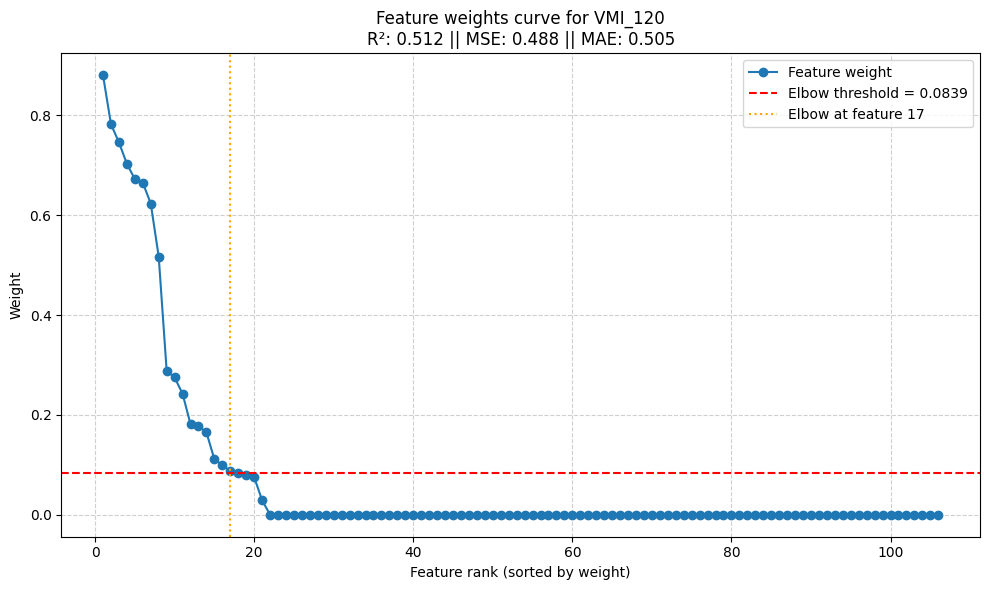

In [8]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical = clinical_df.select_dtypes(include=['number']).columns

scaler = StandardScaler()
clinical_scaled = pd.DataFrame(scaler.fit_transform(clinical_df[numeric_clinical]),
                               columns=clinical_df[numeric_clinical].columns,
                               index=clinical_df[numeric_clinical].index)

df_c25 = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged\merged_konv_radiomics_spine_lesions_features.csv")

sp_c25 = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_CaSupp_25.csv")
sp_konv = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_konv.csv")
sp_vmi40 = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi40.csv")
sp_vmi80 = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi80.csv")
sp_vmi120 = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi120.csv")

significant_c25 = sp_c25[sp_c25["p_value"] < 0.05]['Feature']
significant_konv = sp_konv[sp_konv["p_value"] < 0.05]['Feature']
significant_vmi40 = sp_vmi40[sp_vmi40["p_value"] < 0.05]['Feature']
significant_vmi80 = sp_vmi80[sp_vmi80["p_value"] < 0.05]['Feature']
significant_vmi120 = sp_vmi120[sp_vmi120["p_value"] < 0.05]['Feature']

dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']
significant = [significant_c25, significant_konv, significant_vmi40, significant_vmi80, significant_vmi120]

for df, name, significant_features in zip(dfs, dataset_names, significant):

    scaler = StandardScaler()
    features_scaled = pd.DataFrame(scaler.fit_transform(df[significant_features]),
                                   columns=df[significant_features].columns,
                                   index=df[significant_features].index)

    valid_idx = clinical_scaled['Beta2 microglobulin (mg/l)'].notna()
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=5000)

    X = features_scaled[significant_features][valid_idx]
    y = clinical_scaled['Beta2 microglobulin (mg/l)'][valid_idx]

    lasso.fit(X, y)
    y_pred = lasso.predict(X)

    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    print(name)
    feature_weights_df = pd.DataFrame({'Feature': X.columns, 'Weight': lasso.coef_}).sort_values(by='Weight', ascending=False).reset_index(drop=True)
    print(feature_weights_df)

    imp = np.sort(np.abs(feature_weights_df['Weight'].values))[::-1]
    x = np.arange(1, len(imp) + 1)

    knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
    threshold = imp[knee.knee] if knee.knee is not None else None
    selected_features = feature_weights_df[feature_weights_df['Weight'].abs() > threshold]['Feature'].tolist()
    print(f" Selected features: {selected_features}")

    plt.figure(figsize=(10, 6))
    plt.plot(x, imp, marker='o', label='Feature weight')
    if threshold is not None:
        plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
        plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
    plt.title(f"Feature weights curve for {name}\nR²: {r2:.3f} || MSE: {mse:.3f} || MAE: {mae:.3f}")
    plt.xlabel("Feature rank (sorted by weight)")
    plt.ylabel("Weight")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()